In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from time import time
import os
from dataclasses import replace
from RaTag.core.datatypes import Run, SetPmt, S2Areas
from RaTag.core.config import FitConfig, AlphaCalibrationConfig, FinetuneConfig

In [3]:
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.alphas.alphas_workflow import map_alpha_events
from RaTag.alphas.alphas_calibration import map_alpha_plots, map_alpha_calibrations, resolve_set_calibration
from RaTag.thgem_tpc.drift_workflow import map_drift_physics

from RaTag.thgem_tpc.recoil_workflow import resolve_finetune_s2_fit, map_finetune_fits, map_finetuned_plots
from RaTag.thgem_tpc.recoil_workflow import map_recoil_fits, map_recoil_plots, _resolve_finetune_kwargs
from RaTag.thgem_tpc.multiiso_workflow import map_multiiso_separation, map_multiiso_s2_vs_field, map_multiiso_hist_grid
from RaTag.io import file_ops
from RaTag.core import paths
from RaTag.el_tpc.fit_s2_area import v_crystalball_right
from RaTag.plotting import (plot_s2areas_summary, plot_finetune_s2area,
                            plot_run_s2_vs_field, plot_waveform)

In [4]:
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run43_analysis.yaml'


config = file_ops.load_yaml(config_path)
exec_cfg = config.get('execution', {})
finetune_dict = config.get('finetuning', {})

alpha_config = config.get('energy_mapping', AlphaCalibrationConfig())
alpha_config = AlphaCalibrationConfig(**{k: v for k, v in alpha_config.items() if hasattr(AlphaCalibrationConfig, k)})

fit_config = config.get('fit_config', FitConfig())
fit_config = FitConfig(**{k: v for k, v in fit_config.items() if hasattr(FitConfig, k)})

# Import and hydrate run without raw waveforms:

With hydrate_only in the YAML execution block, the bootstrapper bypasses the full workflow with raw waveforms and only hydrates the cache

In [5]:
run = bootstrap_from_config(config_path)   
# run = map_drift_physics(run, force=True)
# # run = map_recoil_fits(run, config=fit_config, force=True)
# run = map_recoil_plots(run, config=fit_config, force=True)

# run = map_alpha_events(run, force=False)
# run = map_alpha_calibrations(run, config=alpha_config, force=True)
# run = map_alpha_plots(run, force=True)
runm = map_multiiso_separation(run, force=True)

# for iso, iso_run in runm.items():
#     runm[iso] = map_recoil_fits(iso_run, config=fit_config, force=True)
#     _ = map_recoil_plots(runm[iso], config=fit_config, force=True)

  🔹 Hydrating state from cache: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/set_summaries
  → Hydrated 14 PMT Sets and 14 Alpha Sets. (Multi-Isotope: True)

SEPARATING MULTI-ISOTOPE SETS: RUN_43

  Mapping FieldScan_Gate0120_Anode1120...
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies/FieldScan_Gate0120_Anode1120_alpha_energies.npz
    ✓ Separated Th228: 14391 events
    ✓ Separated Ra224: 7875 events
    ✓ Separated Bi212: 2845 events
    ✓ Separated Rn220: 2858 events
    ✓ Separated Po216: 3932 events
    ✓ Separated Po212: 5604 events

  Mapping FieldScan_Gate0188_Anode1188...
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0188_Anode1188_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/pr

# Fine fit undistributed (isotope-agnostic) sets

In [126]:
shape_factors = {
    'beta_L': [],
    'beta_R': [],
    'm_L': [],
    'm_R': []}

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz
    ⚠ Profile likelihood failed for sig_x0. Defaulting to bin error only.
  ✓ Fine-Tuned: μ=15.000 ± 0.509
  ✓ FieldScan_Gate0120_Anode1120: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz


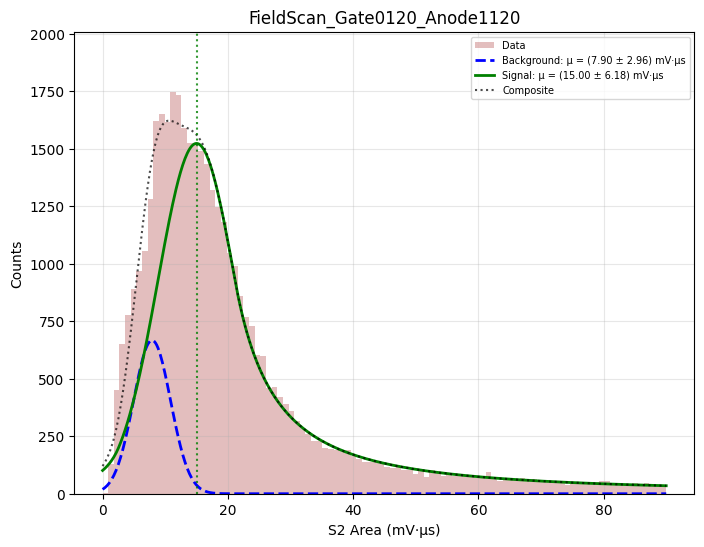

In [85]:
set_idx = 0
set0 = run.sets[set_idx]
config = file_ops.load_yaml(config_path)
finetune_dict = config.get('finetuning', {})
config1_dict = finetune_dict.get(set0.name)
filtered_kwargs = _resolve_finetune_kwargs(finetune_dict, set0.source_dir.name, None)
config1 = FinetuneConfig(**filtered_kwargs)

set1 = resolve_finetune_s2_fit(set0, config=config1, force=True)
s2_areas = file_ops.load_s2areas(set1)
fit_results = {
            'peak_position': set0.area_s2_mean,
            'result_composite': file_ops.load_fit_result(paths.get_fit_path(set1, 's2_areas_finetune'), funcdefs={'v_crystalball_right': v_crystalball_right}),
        }
fig, ax = plt.subplots(figsize=(8, 6))
plot_finetune_s2area(ax, data=s2_areas.areas, config=config1, 
                     fit_result=fit_results, set_name=set0.name, color='brown')

In [77]:
config = file_ops.load_yaml(config_path)
finetune_dict = config.get('finetuning', {})

run = map_finetune_fits(run, finetune_dict=finetune_dict, force=True)
run = map_finetuned_plots(run, finetune_dict=finetune_dict, force=True)


FINE-TUNING S2 AREA DISTRIBUTIONS: RUN_43
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz
    ⚠ Profile likelihood failed for sig_x0. Defaulting to bin error only.
  ✓ Fine-Tuned: μ=15.000 ± 0.509
  ✓ FieldScan_Gate0120_Anode1120: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0188_Anode1188_s2_areas.npz
    ⚠ Profile likelihood failed for sig_x0. Defaulting to bin error only.
  ✓ Fine-Tuned: μ=17.635 ± 0.509
  ✓ FieldScan_Gate0188_Anode1188: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0288_Anode1288_s2_areas.npz
    ⚠ Profile likelihood failed for sig_x0. Defaulting to bin error only.
  ✓ Fine-Tuned: μ=18.584 ± 0.509
  ✓ FieldScan_Gate0288_Anode1288: Computed 'area_s2_fit

# Isotope specific sets

In [71]:
runm['Th228'].sets[11].name

'FieldScan_Gate1440_Anode2640_Th228'

In [12]:
filtered_kwargs = _resolve_finetune_kwargs(finetune_dict, set1.source_dir.name, target_iso)


Resolving fine-tune kwargs for set 'FieldScan_Gate1056_Anode2056' and isotope 'Ra224':
  Global Config: {'bin_cuts': [0.0, 90.0], 'nbins': 100, 'bg_amplitude': {'value': 4000, 'min': 500, 'max': 60000}, 'bg_center': {'value': 4.5, 'min': 4.0, 'max': 12.0}, 'bg_sigma': {'value': 3, 'min': 1, 'max': 8}, 'sig_N': {'value': 2100, 'min': 200, 'max': 5000}, 'sig_m_L': {'value': 1.5, 'min': 1.0, 'max': 2.0}, 'sig_beta_L': {'value': 1.5, 'min': 1.0, 'max': 2.0}, 'sig_m_R': {'value': 1.5, 'min': 1.0, 'max': 2.0}, 'sig_beta_R': {'value': 1.5, 'min': 1.0, 'max': 2.0}, 'sig_sigma': {'value': 5, 'min': 2, 'max': 8}, 'sig_x0': {'value': 25.0, 'min': 20.0, 'max': 50.0}}
  Set Config: {}
  Isotope Config: {}


In [20]:
base_set_name = set1.name
target_isotope = 'Ra224'
global_cfg = finetune_dict.get('global', {})
set_cfg = finetune_dict.get(base_set_name, {})

# Safely extract isotope-specific config without pulling unrelated set-level keys
iso_cfg = set_cfg.get(target_isotope, {}) if target_isotope and isinstance(set_cfg.get(target_isotope), dict) else {}
iso_cfg

{'sig_x0': {'value': 85.0, 'min': 23.0, 'max': 50.0},
 'sig_m_L': {'value': 0.2, 'min': 0.1, 'max': 2.0},
 'sig_beta_L': {'value': 1.5, 'min': 1.0, 'max': 2.0}}


Resolving fine-tune kwargs for set 'FieldScan_Gate1056_Anode2056' and isotope 'Ra224':
  Global Config: {'bin_cuts': [0.0, 90.0], 'nbins': 100, 'bg_amplitude': {'value': 4000, 'min': 500, 'max': 60000}, 'bg_center': {'value': 4.5, 'min': 4.0, 'max': 12.0}, 'bg_sigma': {'value': 3, 'min': 1, 'max': 8}, 'sig_N': {'value': 2100, 'min': 200, 'max': 5000}, 'sig_m_L': {'value': 1.5, 'min': 1.0, 'max': 2.0}, 'sig_beta_L': {'value': 1.5, 'min': 1.0, 'max': 2.0}, 'sig_m_R': {'value': 1.5, 'min': 1.0, 'max': 2.0}, 'sig_beta_R': {'value': 1.5, 'min': 1.0, 'max': 2.0}, 'sig_sigma': {'value': 5, 'min': 2, 'max': 8}, 'sig_x0': {'value': 25.0, 'min': 20.0, 'max': 50.0}}
  Set Config: {}
  Isotope Config: {}
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Ra224/FieldScan_Gate1056_Anode2056_Ra224_s2_areas.npz
    ⚠ Profile likelihood failed for sig_x0. Defaulting to bin error only.
  ✓ Fine-Tuned: μ=23.690 ± 0.509
  ✓ FieldScan_Gate1056_Anode2056_Ra2

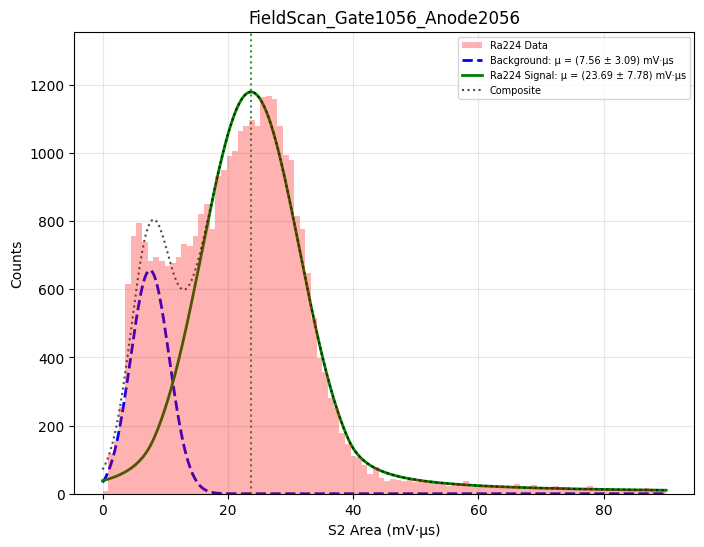

In [ ]:
set_idx = 9
target_iso = 'Ra224'
set1 = runm[target_iso].sets[set_idx]

config = file_ops.load_yaml(config_path)
finetune_dict = config.get('finetuning', {})

# 1. Use the core helper to safely cascade Global -> Set -> Isotope
filtered_kwargs = _resolve_finetune_kwargs(finetune_dict, set1.name, target_iso)
config1 = FinetuneConfig(**filtered_kwargs)

# 2. Execute
set1 = resolve_finetune_s2_fit(set1, config=config1, force=True)

# 3. Plot
s2_areas = file_ops.load_s2areas(set1)
fit_results = {
            'peak_position': set1.area_s2_mean,
            'result_composite': file_ops.load_fit_result(paths.get_fit_path(set1, 's2_areas_finetune'), funcdefs={'v_crystalball_right': v_crystalball_right}),
        }

fig, ax = plt.subplots(figsize=(8, 6))
plot_finetune_s2area(ax, data=s2_areas.areas, config=config1, 
                     fit_result=fit_results, set_name=set1.source_dir.name, color='blue', target_isotope=target_iso)


In [113]:
config1.sig_x0

{'value': 25.0, 'min': 20.0, 'max': 50.0}

In [115]:
fit_results['result_composite'].params

name,value,initial value,min,max,vary,expression
bg_amplitude,5083.08066,4000.0,500.000000,60000.0000,True,
bg_center,7.56162191,4.5,4.00000000,12.0000000,True,
bg_sigma,3.09227066,3.0,1.00000000,8.00000000,True,
sig_N,1178.85573,2100.0,200.000000,5000.00000,True,
sig_beta_L,2.00000000,1.5,1.00000000,2.00000000,True,
sig_m_L,2.00000000,1.5,1.00000000,2.00000000,True,
sig_beta_R,2.00000000,1.5,1.00000000,2.00000000,True,
sig_m_R,1.06469310,1.5,1.00000000,2.00000000,True,
sig_x0,23.6900263,25.0,20.0000000,50.0000000,True,
sig_sigma,7.78185009,5.0,2.00000000,8.00000000,True,



FINE-TUNING S2 AREA DISTRIBUTIONS: RUN_51_Ra224
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/isotope_areas/Ra224/FieldScan_Gate0120_Anode1320_Ra224_s2_areas.npz
  ✓ Fine-Tuned: μ=39.063 ± 3.673
  ✓ FieldScan_Gate0120_Anode1320_Ra224: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/isotope_areas/Ra224/FieldScan_Gate0188_Anode1388_Ra224_s2_areas.npz
  ✓ Fine-Tuned: μ=48.338 ± 2.809
  ✓ FieldScan_Gate0188_Anode1388_Ra224: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/isotope_areas/Ra224/FieldScan_Gate0288_Anode1488_Ra224_s2_areas.npz
  ✓ Fine-Tuned: μ=61.076 ± 2.610
  ✓ FieldScan_Gate0288_Anode1488_Ra224: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/isotope_areas/Ra224/FieldScan_G

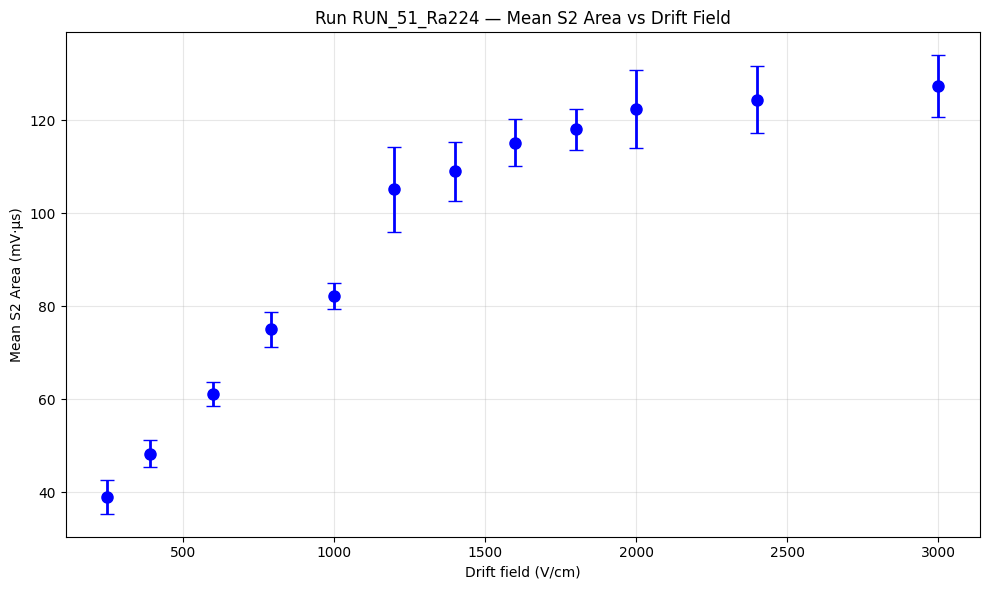

In [52]:
config = file_ops.load_yaml(config_path)
finetune_dict = config.get('finetuning', {})
# for iso, run_iso in runm.items():
for iso, run_iso in [(target_iso, runm[target_iso])]:
    run_iso = map_finetune_fits(run_iso, finetune_dict=finetune_dict, force=True)
    run_iso = map_finetuned_plots(run_iso, finetune_dict=finetune_dict, force=True)
    plot_run_s2_vs_field(run_iso)
    runm[iso] = run_iso  # Update the dict with the finetuned run

In [53]:
run = map_multiiso_s2_vs_field(run, spawned_runs=runm, force=True)
run = map_multiiso_hist_grid(run, spawned_runs=runm, force=True)


PLOTTING MULTI-ISOTOPE S2 VS FIELD: RUN_51
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/plots/s2_areas/multi/RUN_51_s2_vs_field_multiiso.png

PLOTTING MULTI-ISOTOPE HISTOGRAMS: RUN_51
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/isotope_areas/Th228/FieldScan_Gate0120_Anode1320_Th228_s2_areas.npz
  ⚠ Warning: Failed to load fit result from FieldScan_Gate0120_Anode1320_Th228_s2_areas_hist_fit.json: No module named 'scipy.special._special_ufuncs'
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/isotope_areas/Ra224/FieldScan_Gate0120_Anode1320_Ra224_s2_areas.npz
  ⚠ Warning: Failed to load fit result from FieldScan_Gate0120_Anode1320_Ra224_s2_areas_hist_fit.json: No module named 'scipy.special._special_ufuncs'
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/isotope_areas/Th228/FieldScan_Gate0188_Anode1388_Th228_s2_areas.npz
  ⚠ Warning: Failed to load fit

/Users/pabloherrero/sabat/RaTagging/.venv/lib/python3.9/site-packages/lmfit/jsonutils.py:146: UserWarning: Could not unpack dill-encoded callable 'loggamma', saved with Python version 3.13
  warnings.warn(msg)


  ⚠ Warning: Failed to load fit result from FieldScan_Gate0188_Anode1388_Ra224_s2_areas_hist_fit.json: No module named 'scipy.special._special_ufuncs'
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/isotope_areas/Th228/FieldScan_Gate0288_Anode1488_Th228_s2_areas.npz
  ⚠ Warning: Failed to load fit result from FieldScan_Gate0288_Anode1488_Th228_s2_areas_hist_fit.json: No module named 'scipy.special._special_ufuncs'
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/isotope_areas/Ra224/FieldScan_Gate0288_Anode1488_Ra224_s2_areas.npz
  ⚠ Warning: Failed to load fit result from FieldScan_Gate0288_Anode1488_Ra224_s2_areas_hist_fit.json: No module named 'scipy.special._special_ufuncs'
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/isotope_areas/Th228/FieldScan_Gate0380_Anode1580_Th228_s2_areas.npz
  ⚠ Warning: Failed to load fit result from FieldScan_Gate0380_Anode1580_Th228_s2_are

/Users/pabloherrero/sabat/RaTagging/.venv/lib/python3.9/site-packages/lmfit/jsonutils.py:146: UserWarning: Could not unpack dill-encoded callable 'erf', saved with Python version 3.13
  warnings.warn(msg)
/Users/pabloherrero/sabat/RaTagging/.venv/lib/python3.9/site-packages/lmfit/jsonutils.py:146: UserWarning: Could not unpack dill-encoded callable 'gamma', saved with Python version 3.13
  warnings.warn(msg)
/Users/pabloherrero/sabat/RaTagging/.venv/lib/python3.9/site-packages/lmfit/jsonutils.py:146: UserWarning: Could not unpack dill-encoded callable 'betaln', saved with Python version 3.13
  warnings.warn(msg)


  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN51_EL30kVcm/plots/s2_areas/multi/RUN_51_histograms_multiiso.png
